In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:

graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

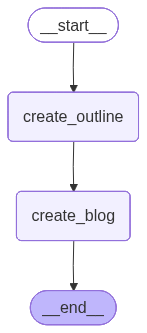

In [10]:
workflow

In [8]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'This outline will help you structure a comprehensive and engaging blog post about the rise of AI in India.\n\n---\n\n## Blog Outline: The AI Surge: Unpacking India\'s Ascent in Artificial Intelligence\n\n**Target Audience:** Tech enthusiasts, business leaders, policymakers, students, anyone interested in AI and India\'s economic growth.\n**Tone:** Informative, optimistic, slightly analytical, forward-looking.\n**Approximate Word Count:** 1200-1800 words (depending on depth of each point).\n\n---\n\n### I. Catchy Title Options:\n*   The AI Surge: Unpacking India\'s Ascent in Artificial Intelligence\n*   India\'s AI Revolution: From Outsourcing Hub to Innovation Powerhouse\n*   Rising AI Tiger: How India is Redefining the Global AI Landscape\n*   Beyond the Hype: The Real Rise of AI in India\n\n### II. Introduction (Approx. 150-200 words)\n*   **A. Global Context:** Briefly touch upon the global AI boom and its transformative potential.\n*   *

In [9]:
print(final_state['content'])

# India's AI Moment: Charting the Rise of Artificial Intelligence in the Subcontinent

## I. Introduction: Setting the Stage

### A. The Global AI Revolution

Artificial Intelligence (AI) is no longer a futuristic concept confined to sci-fi novels; it is the defining technology of our 21st century. From powering personalized recommendations on streaming platforms to accelerating scientific discoveries, AI’s pervasive influence is reshaping industries, economies, and societies worldwide at an unprecedented pace. It’s a global revolution, and no nation can afford to be left behind.

### B. India's Unique Position

Amidst this global transformation, India emerges not just as a participant, but a crucial player. With its rapidly growing digital economy, a youthful and massive tech-savvy population, and an insatiable appetite for innovation, India stands at a pivotal juncture. It's poised to leverage AI not merely as a consumer of global technologies, but as a significant contributor, shapi